##Business Problem
The organization is experiencing a noticeable increase in employee attrition, which is leading to:

Increased hiring and onboarding costs  

Loss of experienced workforce  

Reduced productivity and team stability  

Impact on overall business performance  

Currently, there is no proactive mechanism to identify employees who are likely to leave the organization.

The objective is to build a predictive system that can identify employees at risk of attrition and provide actionable insights to the Human Resources (HR) team for timely intervention.

##Understanding the dataset
Input/Dependent Variables - Age, BusinessTravel, DailyRate, Department,
DistanceFromHome, Education, EducationField, EnvironmentSatisfaction, Gender, HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction,
MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked, OverTime,
PercentSalaryHike, RelationshipSatisfaction, StockOptionLevel,
TotalWorkingYears, TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany,
YearsInCurrentRole, YearsSinceLastPromotion,YearsWithCurrManager.

Target/Output Variable -Attrition (Yes/No)


In [95]:
#Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

#Modeling and Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [96]:
#Loading the dataset
df = pd.read_csv('/content/HR-Employee-Attrition.csv')

In [97]:
#Displaying the First 5 Rows for Verification
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


##EDA Process Begins

In [98]:
df.shape

(1470, 35)

The dataset contains 1,470 samples (rows) and 35 variables (columns).

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

The dataset consists of 1,470 rows and 35 columns, with all columns containing complete (non-null) values.
It includes 26 numerical features and 9 categorical features, requiring encoding before model building.

In [100]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


The descriptive statistics show that the dataset contains 1,470 observations for all numerical variables, indicating no missing values in these columns. The average employee is approximately 37 years old, earns a monthly income of around 6,503, has about 11 years of total work experience, and has been with the company for about 7 years.
Some features such as EmployeeCount,Over 18 and StandardHours have zero standard deviation (constant values), meaning they do not provide useful information for model building and can be dropped.

In [101]:
# To find columns where all values are unique
unique_value_cols = [col for col in df.columns if df[col].nunique() == len(df)]

print("Columns containing unique values are:", unique_value_cols)

Columns containing unique values are: ['EmployeeNumber']


The output shows that 'EmployeeNumber' is the only column with unique values for every employee record. Since it acts as a unique identifier and does not carry predictive information, it can be dropped before model building.

In [102]:
#To find the columns where all the values are same
constant_cols = df.columns[df.nunique() == 1].tolist()

print("Columns containing all the same values are -",constant_cols)

Columns containing all the same values are - ['EmployeeCount', 'Over18', 'StandardHours']


The output shows that 'EmployeeCount', 'Over18', and 'StandardHours' contain the same value for all records.
Since these columns have no variation, they do not provide useful information and can be removed before model building.

In [103]:
#Drop the columns that may not contribute to predictie modelling.
df.drop(columns=['EmployeeCount','EmployeeNumber','Over18','StandardHours'], axis=1, inplace=True)

The columns 'EmployeeCount', 'EmployeeNumber', 'Over18', and 'StandardHours' have been dropped from the dataset.
These columns were either unique identifiers or constant features and therefore do not provide useful information for model training.

In [104]:
df.shape

(1470, 31)

In [105]:
#Checking null values
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


The dataset has no missing values in any of the column, ensuring that no missing value treatment is required & it is ready for further analysis and model building.

In [106]:
print('Total number of duplicate rows -',int(df.duplicated().sum()))

Total number of duplicate rows - 0


The duplicate check confirms that the dataset has zero duplicate rows, so no duplicate removal is required, ensuring data quality and preventing bias during model training.

In [107]:
#Split the dataset into categorical and numerical columns
cat = df.select_dtypes(include = "object").columns
num = df.select_dtypes(exclude= "object").columns

The dataset is divided into categorical and numerical columns based on their data types.
This separation helps apply appropriate preprocessing techniques, such as encoding for categorical features and scaling for numerical features.

In [108]:
print('Columns containing the categorical values are - ',cat.tolist())

Columns containing the categorical values are -  ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [109]:
print('Columns containing the numerical values are - ',num.tolist())

Columns containing the numerical values are -  ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [110]:
#To find out any error values if exsists in the dataset
for col in df.columns:
  if df[col].dtype == "object":
      print(f"\nColumn: {col}")
      print(df[col].value_counts(dropna=False))


Column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Column: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Column: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Column: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Column: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Column: JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int

No error values were found in the dataset.

In [111]:
for col in num:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
  print(f'\nColumn Name: {col}')
  print(f'Lower Limit: {lower_limit}')
  print(f'Upper Limit: {upper_limit}')
  print(f'Number of Outliers found : {len(outliers)}')

  # Cap the outliers
  df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
  df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])


Column Name: Age
Lower Limit: 10.5
Upper Limit: 62.5
Number of Outliers found : 0

Column Name: DailyRate
Lower Limit: -573.0
Upper Limit: 2195.0
Number of Outliers found : 0

Column Name: DistanceFromHome
Lower Limit: -16.0
Upper Limit: 32.0
Number of Outliers found : 0

Column Name: Education
Lower Limit: -1.0
Upper Limit: 7.0
Number of Outliers found : 0

Column Name: EnvironmentSatisfaction
Lower Limit: -1.0
Upper Limit: 7.0
Number of Outliers found : 0

Column Name: HourlyRate
Lower Limit: -5.625
Upper Limit: 137.375
Number of Outliers found : 0

Column Name: JobInvolvement
Lower Limit: 0.5
Upper Limit: 4.5
Number of Outliers found : 0

Column Name: JobLevel
Lower Limit: -2.0
Upper Limit: 6.0
Number of Outliers found : 0

Column Name: JobSatisfaction
Lower Limit: -1.0
Upper Limit: 7.0
Number of Outliers found : 0

Column Name: MonthlyIncome
Lower Limit: -5291.0
Upper Limit: 16581.0
Number of Outliers found : 114

Column Name: MonthlyRate
Lower Limit: -10574.75
Upper Limit: 39083.

Outliers were identified for several numerical columns using the Interquartile Range (IQR) method. For each column where outliers were found, they were capped at the calculated lower and upper limits to mitigate their impact on model performance. Columns with no outliers (0 found) indicate a more uniform distribution within the typical range.

In [112]:
constant_cols = df.columns[df.nunique() == 1].tolist()

print("Columns containing all the same values are -",constant_cols)

Columns containing all the same values are - ['PerformanceRating']


In [113]:
# Drop 'PerformanceRating' as it has very low variance and provides limited predictive information after capping.
df.drop(columns=['PerformanceRating'], inplace=True)

In [114]:
df.shape

(1470, 30)

In [115]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102.0,Sales,1.0,2.0,Life Sciences,2.0,Female,...,11.0,1.0,0.0,8.0,0.5,1.0,6.0,4.0,0.0,5.0
1,49.0,No,Travel_Frequently,279.0,Research & Development,8.0,1.0,Life Sciences,3.0,Male,...,23.0,4.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37.0,Yes,Travel_Rarely,1373.0,Research & Development,2.0,2.0,Other,4.0,Male,...,15.0,2.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33.0,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,4.0,Female,...,11.0,3.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,Male,...,12.0,4.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36.0,No,Travel_Frequently,884.0,Research & Development,23.0,2.0,Medical,3.0,Male,...,17.0,3.0,1.0,17.0,3.0,3.0,5.0,2.0,0.0,3.0
1466,39.0,No,Travel_Rarely,613.0,Research & Development,6.0,1.0,Medical,4.0,Male,...,15.0,1.0,1.0,9.0,4.5,3.0,7.0,7.0,1.0,7.0
1467,27.0,No,Travel_Rarely,155.0,Research & Development,4.0,3.0,Life Sciences,2.0,Male,...,20.0,2.0,1.0,6.0,0.5,3.0,6.0,2.0,0.0,3.0
1468,49.0,No,Travel_Frequently,1023.0,Sales,2.0,3.0,Medical,4.0,Male,...,14.0,4.0,0.0,17.0,3.0,2.0,9.0,6.0,0.0,8.0


In [116]:
df.shape

(1470, 30)

In [117]:
## Convert categorical variables to numerical
le = LabelEncoder()
for i in cat:
  df[i] = le.fit_transform(df[i])

The categorical features are converted into numerical values using Label Encoding.This transformation enables machine learning algorithms to process categorical data during model training.

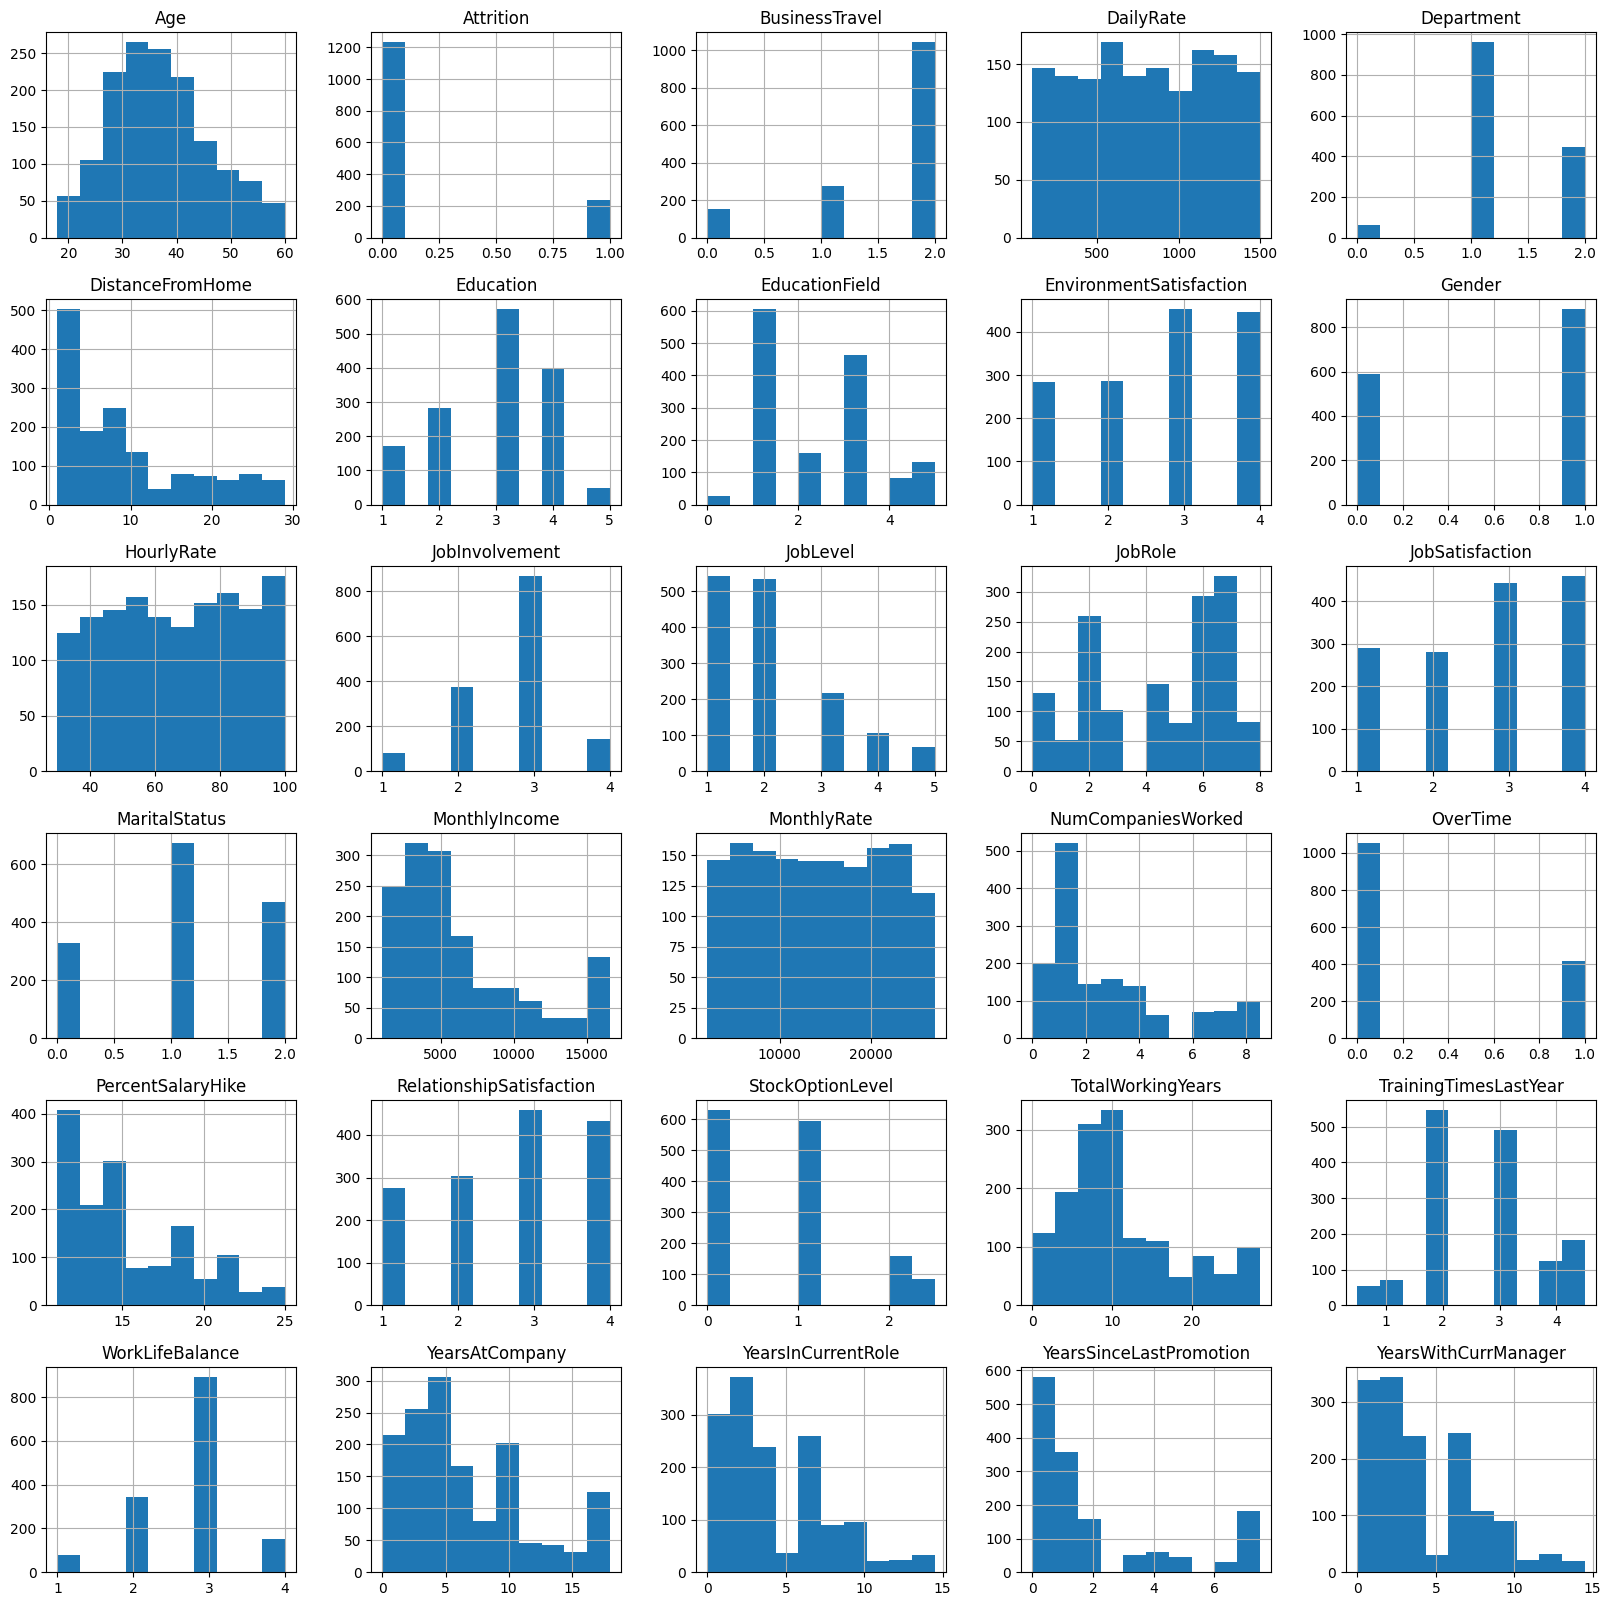

In [118]:
## Univariate analysis

df.hist(figsize=(20,20))
plt.show()

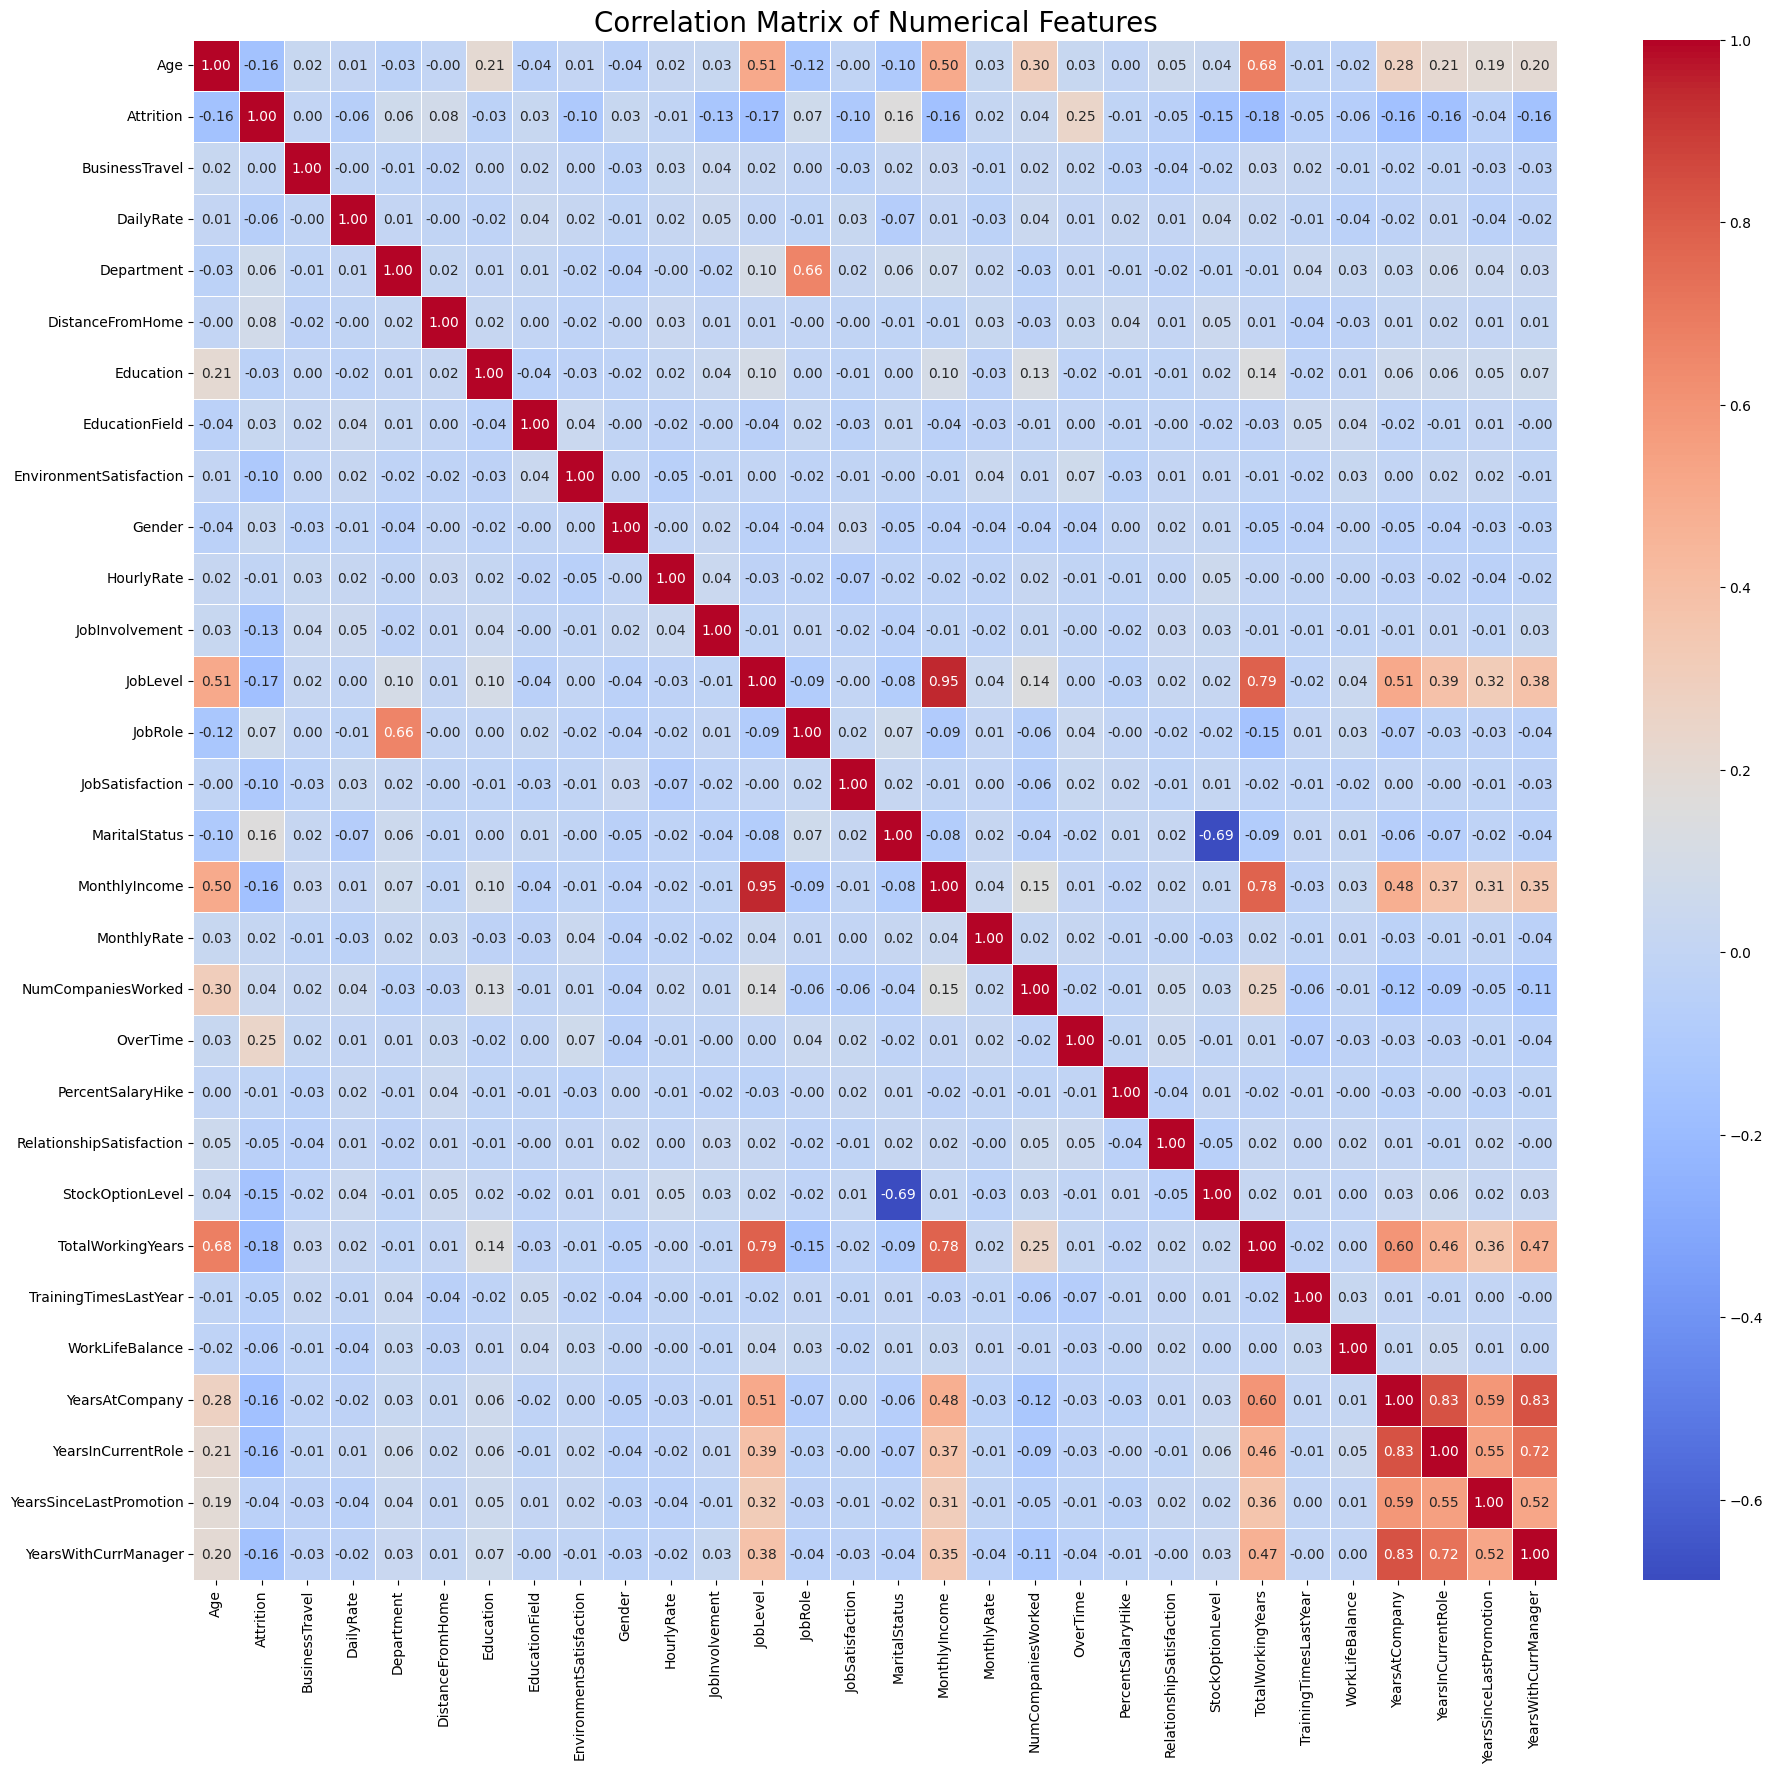

In [119]:
# Bivariate analysis - Correlation Matrix

plt.figure(figsize=(22, 20)) # Adjust figure size for better readability
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

The correlation heatmap shows that OverTime (0.25), MaritalStatus (0.16), and DistanceFromHome (0.08) have the highest positive correlations with Attrition.TotalWorkingYears (-0.18), JobLevel (-0.17), and MonthlyIncome (-0.16) have the strongest negative correlations.

In [120]:
## Target colum balance check

df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


The dataset is imbalanced, as the majority of employees belong to the 'No Attrition' class.

##ML Model Building

In [121]:
## Split the dataset into X,y

X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [122]:
X

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,2,1102.0,2,1.0,2.0,1,2.0,0,94.0,...,11.0,1.0,0.0,8.0,0.5,1.0,6.0,4.0,0.0,5.0
1,49.0,1,279.0,1,8.0,1.0,1,3.0,1,61.0,...,23.0,4.0,1.0,10.0,3.0,3.0,10.0,7.0,1.0,7.0
2,37.0,2,1373.0,1,2.0,2.0,4,4.0,1,92.0,...,15.0,2.0,0.0,7.0,3.0,3.0,0.0,0.0,0.0,0.0
3,33.0,1,1392.0,1,3.0,4.0,1,4.0,0,56.0,...,11.0,3.0,0.0,8.0,3.0,3.0,8.0,7.0,3.0,0.0
4,27.0,2,591.0,1,2.0,1.0,3,1.0,1,40.0,...,12.0,4.0,1.0,6.0,3.0,3.0,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36.0,1,884.0,1,23.0,2.0,3,3.0,1,41.0,...,17.0,3.0,1.0,17.0,3.0,3.0,5.0,2.0,0.0,3.0
1466,39.0,2,613.0,1,6.0,1.0,3,4.0,1,42.0,...,15.0,1.0,1.0,9.0,4.5,3.0,7.0,7.0,1.0,7.0
1467,27.0,2,155.0,1,4.0,3.0,1,2.0,1,87.0,...,20.0,2.0,1.0,6.0,0.5,3.0,6.0,2.0,0.0,3.0
1468,49.0,1,1023.0,2,2.0,3.0,3,4.0,1,63.0,...,14.0,4.0,0.0,17.0,3.0,2.0,9.0,6.0,0.0,8.0


In [123]:
y

,Attrition
0,1
1,0
2,1
3,0
4,0
...,...
1465,0
1466,0
1467,0
1468,0


In [124]:
## train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
## standardize the dataset

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [126]:
X_train

array([[-1.38855944,  0.58928051, -1.10813858, ..., -0.89789357,
        -0.76500863, -1.15473274],
       [-2.04073779, -2.46355596, -1.2634814 , ..., -1.17943545,
        -0.76500863, -1.15473274],
       [-0.84507748,  0.58928051,  1.10364737, ..., -0.61635168,
        -0.76500863, -0.57907962],
       ...,
       [-1.60595222, -0.93713773,  1.1258392 , ..., -1.17943545,
        -0.76500863, -1.15473274],
       [-0.84507748,  0.58928051,  1.42666182, ..., -0.3348098 ,
        -0.76500863, -0.29125306],
       [ 1.43754676,  0.58928051, -1.32019386, ..., -1.17943545,
        -0.76500863, -1.15473274]])

In [127]:
## Multi model cross validation

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

cv = StratifiedKFold(n_splits=5, shuffle=True)
score = ['accuracy', 'precision', 'recall', 'f1']

cv_results = []


In [128]:
print("Running 5 fold stratefied Cross validation")

for name, model in models.items():
  scores = cross_validate(model, X_train, y_train, cv=cv, scoring=score)

  cv_results.append({
      'model': name,
      'accuracy': scores['test_accuracy'].mean(),
      'precision': scores['test_precision'].mean(),
      'recall': scores['test_recall'].mean(),
      'f1': scores['test_f1'].mean()
  })

cv_results = pd.DataFrame(cv_results).sort_values(by='f1', ascending=False).round(3)
print("\nCross validation results sorted by F1 score:")
print(cv_results.to_string(index=False))

Running 5 fold stratefied Cross validation

Cross validation results sorted by F1 score:
              model  accuracy  precision  recall    f1
        Naive Bayes     0.783      0.411   0.636 0.499
Logistic Regression     0.860      0.651   0.354 0.458
      Decision Tree     0.781      0.368   0.410 0.384
      Random Forest     0.855      0.761   0.202 0.316
K-Nearest Neighbors     0.841      0.643   0.136 0.224


Naive Bayes was selected as the best model because it achieved the highest F1-score during 5-fold Stratified Cross-Validation.

In [129]:
## Final model selection - select top performing model based on F1 score

best_model = cv_results.iloc[0]['model']
print(f"\nBest performing model: {best_model}")


Best performing model: Naive Bayes


In [130]:
# Perform hyperparameter tuning on the best-performing model using GridSearchCV

# Define the parameter grid
param_grid = {'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7]}

# Create the model
nb = GaussianNB()

# Perform Grid Search
grid = GridSearchCV(estimator=nb,param_grid=param_grid,cv=5,scoring='f1',n_jobs=-1)

grid.fit(X_train, y_train)

# Best model after tuning
best_model = grid.best_estimator_

print("Best Parameters :", grid.best_params_)
print("Best Cross Validation F1 Score :", round(grid.best_score_,4))

Best Parameters : {'var_smoothing': 1e-12}
Best Cross Validation F1 Score : 0.4878


Hyperparameter tuning selected 'var_smoothing = 1e-12' as the best parameter.The optimized model achieved a cross-validation F1-score of 0.4878.

In [131]:
# Make predictions
y_pred = best_model.predict(X_test)

In [132]:

# Display evaluation metrics
print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision :", round(precision_score(y_test, y_pred),4))
print("Recall :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))

Accuracy : 0.8265
Precision : 0.4
Recall : 0.6154
F1 Score : 0.4848


In [133]:
# Display the confusion matrix for the tuned model
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[219  36]
 [ 15  24]]


In [134]:
# Predict attrition for a new employee record

new_emp = pd.DataFrame([{
    'Age': 35,
    'BusinessTravel': 2,
    'DailyRate': 500,
    'Department': 1,
    'DistanceFromHome': 10,
    'Education': 3,
    'EducationField': 2,
    'EnvironmentSatisfaction': 3,
    'Gender': 1,
    'HourlyRate': 65,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobRole': 4,
    'JobSatisfaction': 4,
    'MaritalStatus': 1,
    'MonthlyIncome': 8000,
    'MonthlyRate': 15000,
    'NumCompaniesWorked': 2,
    'OverTime': 1,
    'PercentSalaryHike': 15,
    'RelationshipSatisfaction': 3,
    'StockOptionLevel': 1,
    'TotalWorkingYears': 10,
    'TrainingTimesLastYear': 3,
    'WorkLifeBalance': 3,
    'YearsAtCompany': 5,
    'YearsInCurrentRole': 3,
    'YearsSinceLastPromotion': 2,
    'YearsWithCurrManager': 4
}])

In [135]:
# Scale the new employee data using the same scaler fitted on the training data
new_emp_scaled = scaler.transform(new_emp)

# Predict whether the employee is likely to leave or stay
prediction = best_model.predict(new_emp_scaled)

if prediction[0] == 1:
    print("Prediction : Employee is likely to leave.")
else:
    print("Prediction : Employee is likely to stay.")

Prediction : Employee is likely to stay.


In [136]:
new_emp_two = pd.DataFrame([{
    'Age': 24,
    'BusinessTravel': 2,
    'DailyRate': 1200,
    'Department': 2,
    'DistanceFromHome': 28,
    'Education': 2,
    'EducationField': 1,
    'EnvironmentSatisfaction': 1,
    'Gender': 1,
    'HourlyRate': 40,
    'JobInvolvement': 2,
    'JobLevel': 1,
    'JobRole': 7,
    'JobSatisfaction': 1,
    'MaritalStatus': 0,
    'MonthlyIncome': 2500,
    'MonthlyRate': 21000,
    'NumCompaniesWorked': 5,
    'OverTime': 1,
    'PercentSalaryHike': 11,
    'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 2,
    'TrainingTimesLastYear': 1,
    'WorkLifeBalance': 1,
    'YearsAtCompany': 1,
    'YearsInCurrentRole': 0,
    'YearsSinceLastPromotion': 0,
    'YearsWithCurrManager': 0
}])

In [137]:
new_emp_scaled = scaler.transform(new_emp_two)
prediction = best_model.predict(new_emp_scaled)

if prediction[0] == 1:
    print("Prediction : Employee is likely to leave.")
else:
    print("Prediction : Employee is likely to stay.")

Prediction : Employee is likely to leave.


In [138]:
new_emp_three = pd.DataFrame([{
    'Age': 42,
    'BusinessTravel': 0,
    'DailyRate': 800,
    'Department': 1,
    'DistanceFromHome': 5,
    'Education': 4,
    'EducationField': 2,
    'EnvironmentSatisfaction': 4,
    'Gender': 1,
    'HourlyRate': 70,
    'JobInvolvement': 4,
    'JobLevel': 3,
    'JobRole': 4,
    'JobSatisfaction': 4,
    'MaritalStatus': 1,
    'MonthlyIncome': 12000,
    'MonthlyRate': 18000,
    'NumCompaniesWorked': 1,
    'OverTime': 0,
    'PercentSalaryHike': 18,
    'RelationshipSatisfaction': 4,
    'StockOptionLevel': 2,
    'TotalWorkingYears': 18,
    'TrainingTimesLastYear': 3,
    'WorkLifeBalance': 4,
    'YearsAtCompany': 12,
    'YearsInCurrentRole': 6,
    'YearsSinceLastPromotion': 2,
    'YearsWithCurrManager': 8
}])

In [139]:
new_emp_scaled = scaler.transform(new_emp_three)
prediction = best_model.predict(new_emp_scaled)

if prediction[0] == 1:
    print("Prediction : Employee is likely to leave.")
else:
    print("Prediction : Employee is likely to stay.")

Prediction : Employee is likely to stay.


In [140]:
# Train a Random Forest model to identify the most important features influencing employee attrition
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest for feature importance
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

# Create a DataFrame of feature importance scores
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.reset_index(drop=True, inplace=True)
feature_importance

,Feature,Importance
0,MonthlyIncome,0.082222
1,OverTime,0.068712
2,Age,0.058792
3,DailyRate,0.056404
4,MonthlyRate,0.050435
5,HourlyRate,0.047590
6,TotalWorkingYears,0.047533
7,DistanceFromHome,0.047332
8,NumCompaniesWorked,0.040956
9,YearsAtCompany,0.036623


**Note:**
Gaussian Naive Bayes was selected as the final prediction model because it achieved the best F1-score. Since Gaussian Naive Bayes does not provide built-in feature importance scores, a Random Forest model was trained separately to identify the most influential features affecting employee attrition and support business insights.

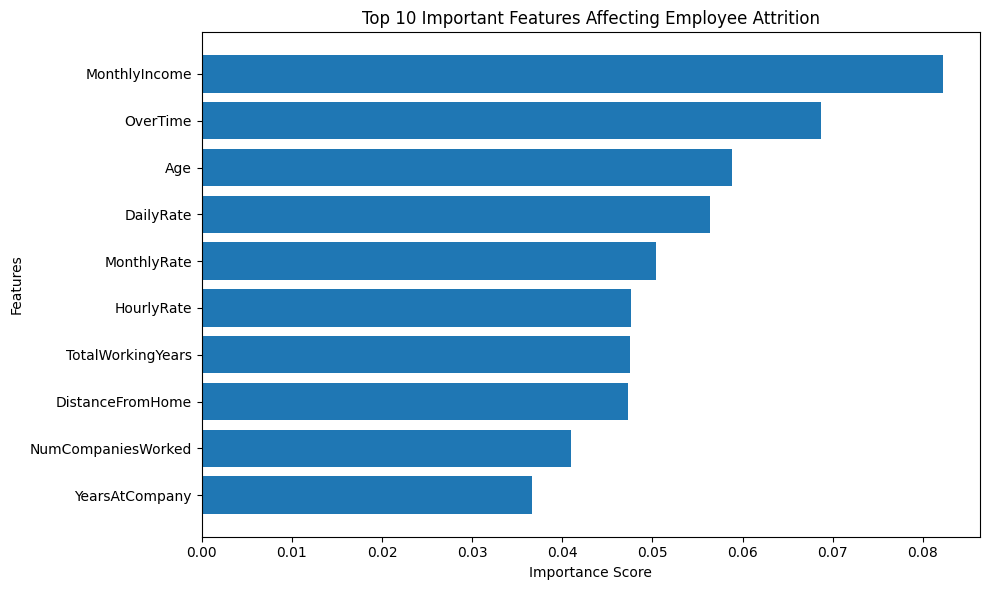

In [141]:
import matplotlib.pyplot as plt

# Visualize the top 10 most important features influencing employee attrition
fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

ax.set_xlabel("Importance Score")
ax.set_ylabel("Features")
ax.set_title("Top 10 Important Features Affecting Employee Attrition")

ax.invert_yaxis()

plt.tight_layout()
plt.show()

##**Feature Importance Insights** -

**MonthlyIncome** is the most influential feature affecting employee attrition, indicating that compensation plays a major role in employee retention.
**OverTime** is the second most important factor, suggesting that employees who work excessive overtime are more likely to leave.
**Age** also has a significant impact, showing that attrition varies across different age groups.

**DailyRate**, **MonthlyRate**, and **HourlyRate** contribute moderately to predicting attrition, highlighting the influence of employee compensation.
**TotalWorkingYears**, **DistanceFromHome**, **NumCompaniesWorked**, and **YearsAtCompany** also affect attrition, indicating that work experience, commuting distance, job stability, and employee tenure play important roles in retention.

##**Business Recommendations**
1. Enhance Employee Compensation
Since **MonthlyIncome** is the most influential factor affecting attrition, the company should periodically review salary structures and offer competitive compensation packages to improve employee retention.
2. Reduce Excessive Overtime
As **OverTime** is one of the top contributors to attrition, management should monitor employee workloads, reduce excessive overtime, and promote a healthy work-life balance.
3. Develop Age-Specific Retention Strategies
Since **Age** significantly influences employee attrition, the organization should design targeted retention programs, career development opportunities, and mentoring initiatives for employees at different career stages.
4. Review Overall Compensation Policies
The importance of **DailyRate**, **MonthlyRate**, and **HourlyRate** indicates that compensation-related policies impact employee retention. Regular market benchmarking and performance-based rewards can help retain valuable employees.
5. Improve Employee Retention Through Career Development
As **TotalWorkingYears**, **YearsAtCompany**, and **NumCompaniesWorked** contribute to attrition prediction, the company should provide clear career progression, training programs, and internal growth opportunities to encourage long-term commitment.
6. Support Employees with Long Commutes
Since **DistanceFromHome** is an important factor, the organization should consider flexible working arrangements, transportation assistance, or hybrid work options (where applicable) to improve employee satisfaction.

##**Conclusion**

This project successfully developed a machine learning model to predict employee attrition using the IBM HR Analytics dataset. Multiple classification algorithms were evaluated using cross-validation, and Gaussian Naive Bayes was selected as the final model based on its F1-score. Hyperparameter tuning further optimized the model's performance. Feature importance analysis highlighted compensation, overtime, age, and work experience as the primary drivers of employee attrition. These insights were translated into actionable business recommendations that can help organizations improve employee retention and workforce planning.